## DSC 680
### Project #2 - Diamond Price Prediction
### Author - Era Ebhodaghe

In [4]:
#importing libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import plotly.express as px

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split,RandomizedSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error


In [5]:
#loading dataset
df = pd.read_csv('/Users/valuedcustomer/Documents/Bellvue/DSC 680 - Applied Data Science/Project 2/diamonds.csv')
df.head(2)

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31


#### Feature description:

#### price price in US dollars ($326--$18,823)This is the target column containing tags for the features. 

#### The 4 Cs of Diamonds:-

#### carat (0.2--5.01) The carat is the diamond’s physical weight measured in metric carats.  One carat equals 1/5 gram and is subdivided into 100 points. Carat weight is the most objective grade of the 4Cs. 

#### cut (Fair, Good, Very Good, Premium, Ideal) In determining the quality of the cut, the diamond grader evaluates the cutter’s skill in the fashioning of the diamond. The more precise the diamond is cut, the more captivating the diamond is to the eye.  

#### color, from J (worst) to D (best) The colour of gem-quality diamonds occurs in many hues. In the range from colourless to light yellow or light brown. Colourless diamonds are the rarest. Other natural colours (blue, red, pink for example) are known as "fancy,” and their colour grading is different than from white colorless diamonds.  

#### clarity (I1 (worst), SI2, SI1, VS2, VS1, VVS2, VVS1, IF (best)) Diamonds can have internal characteristics known as inclusions or external characteristics known as blemishes. Diamonds without inclusions or blemishes are rare; however, most characteristics can only be seen with magnification.  

#### Dimensions

#### x length in mm (0--10.74)

#### y width in mm (0--58.9)

#### z depth in mm (0--31.8)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  53940 non-null  int64  
 1   carat       53940 non-null  float64
 2   cut         53940 non-null  object 
 3   color       53940 non-null  object 
 4   clarity     53940 non-null  object 
 5   depth       53940 non-null  float64
 6   table       53940 non-null  float64
 7   price       53940 non-null  int64  
 8   x           53940 non-null  float64
 9   y           53940 non-null  float64
 10  z           53940 non-null  float64
dtypes: float64(6), int64(2), object(3)
memory usage: 4.5+ MB


In [8]:
df.describe()

,Unnamed: 0,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,26970.500000,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,15571.281097,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,1.000000,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,13485.750000,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,26970.500000,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,40455.250000,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,53940.000000,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


## Data Cleaning

#### Dropping Unwanted Columns

In [11]:
columns_to_drop = [0]  # Index positions of 'Profession' and 'Favorite_Coffee'
df = df.drop(df.columns[columns_to_drop], axis=1)

In [12]:
df.head(2)

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31


### Checking for missing values

In [14]:
df.isnull().sum().sum()

0

### Checking for duplicates and dropping them

In [16]:
print("Number of duplicate data : ",df.duplicated().sum())

Number of duplicate data :  146


In [17]:
df = df.drop_duplicates()

### Checking for and dropping outliers

In [19]:
#Dropping dimentionless diamonds
df = df.drop(df[df["x"]==0].index)
df = df.drop(df[df["y"]==0].index)
df = df.drop(df[df["z"]==0].index)
df.shape

(53775, 10)

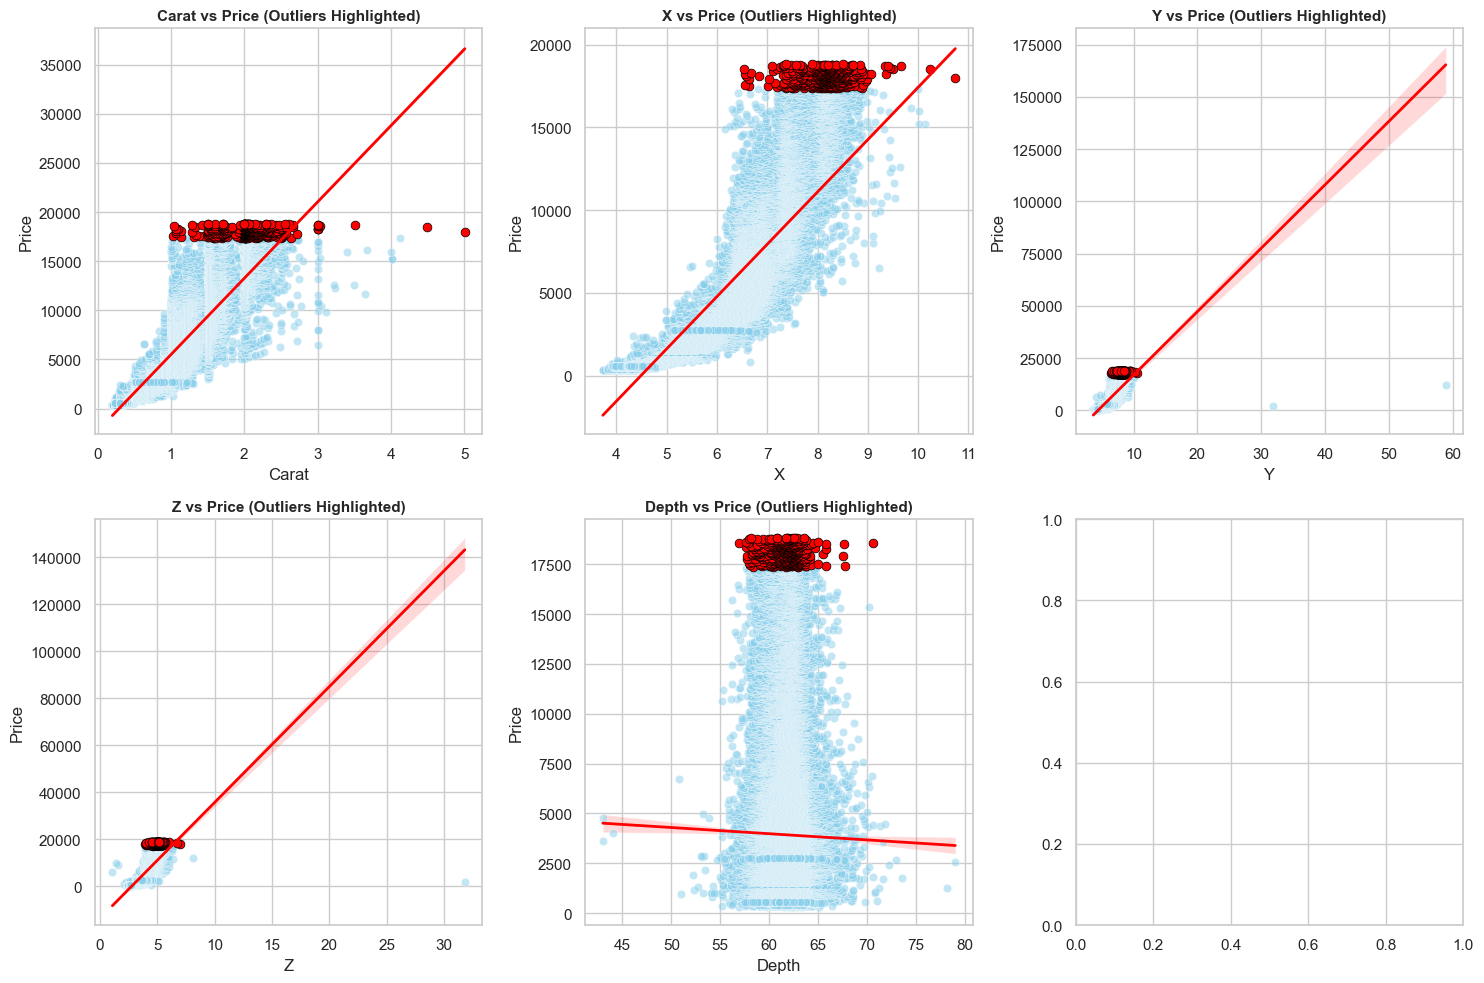

In [20]:

sns.set(style="whitegrid")

# Define numeric and categorical variables
numeric_vars = ['carat', 'x', 'y', 'z', 'depth']
categorical_vars = ['color', 'cut', 'clarity']

# Define a price threshold for outliers (top 1%)
price_threshold = df['price'].quantile(0.99)
df['is_outlier'] = df['price'] > price_threshold

# ---- Numeric Variables: Regression + Outliers ----
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for i, var in enumerate(numeric_vars):
    ax = axes[i // 3, i % 3]

    # Regression line
    sns.regplot(
        data=df,
        x=var,
        y='price',
        scatter=False,
        line_kws={'color': 'red', 'lw': 2},
        ax=ax
    )

    # Normal points
    sns.scatterplot(
        data=df[df['is_outlier'] == False],
        x=var,
        y='price',
        color='skyblue',
        alpha=0.5,
        ax=ax
    )

    # Outliers
    sns.scatterplot(
        data=df[df['is_outlier'] == True],
        x=var,
        y='price',
        color='red',
        edgecolor='black',
        s=40,
        ax=ax
    )

    ax.set_title(f"{var.title()} vs Price (Outliers Highlighted)", fontsize=11, fontweight='bold')
    ax.set_xlabel(var.title())
    ax.set_ylabel("Price")

plt.tight_layout()
plt.show()






#### Based on the outliers visualized, I will proceed to dropping the outliers

In [22]:
#Dropping the outliers. 
df = df[(df["depth"]<75)&(df["depth"]>45)]
df = df[(df["table"]<80)&(df["table"]>40)]
df = df[(df["x"]<30)]
df = df[(df["y"]<30)]
df = df[(df["z"]<30)&(df["z"]>2)]
df.shape

(53763, 11)

# Data Visualization

#### Plotting individual variables against diamond price

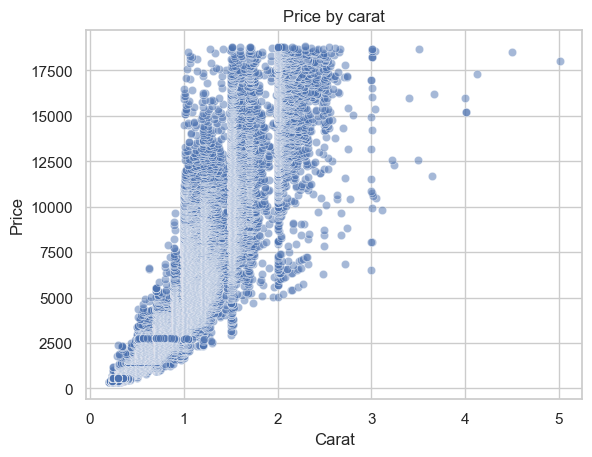

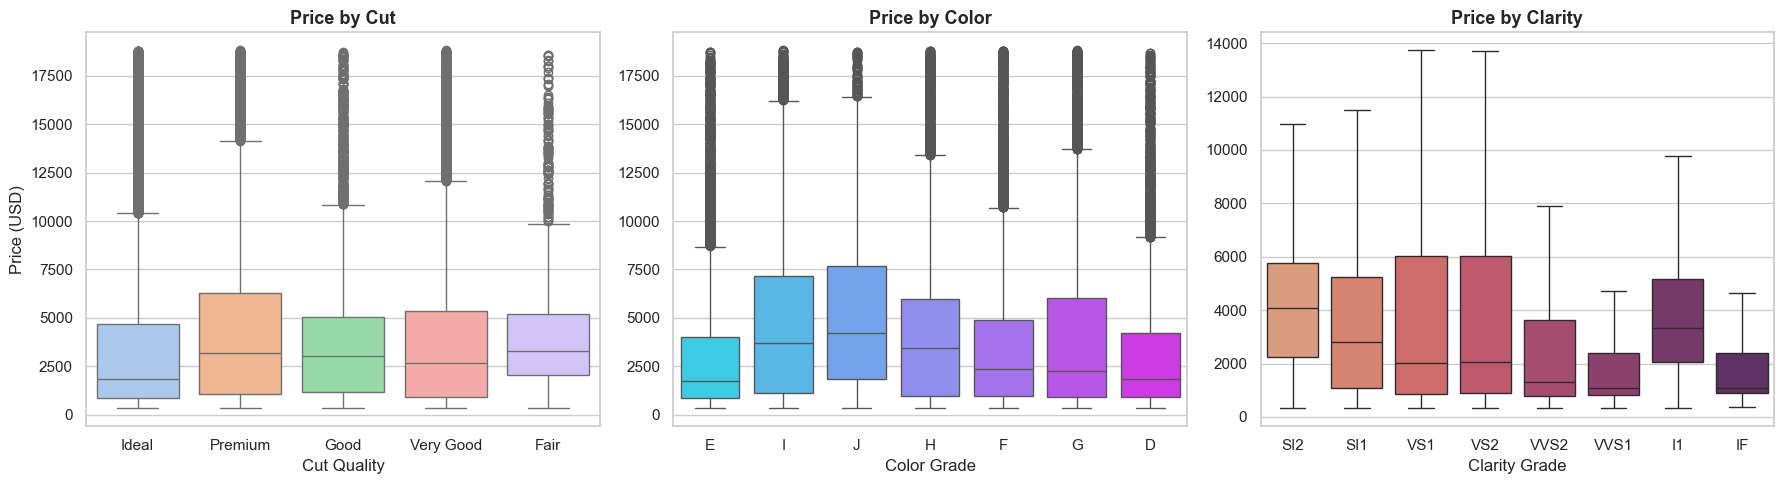

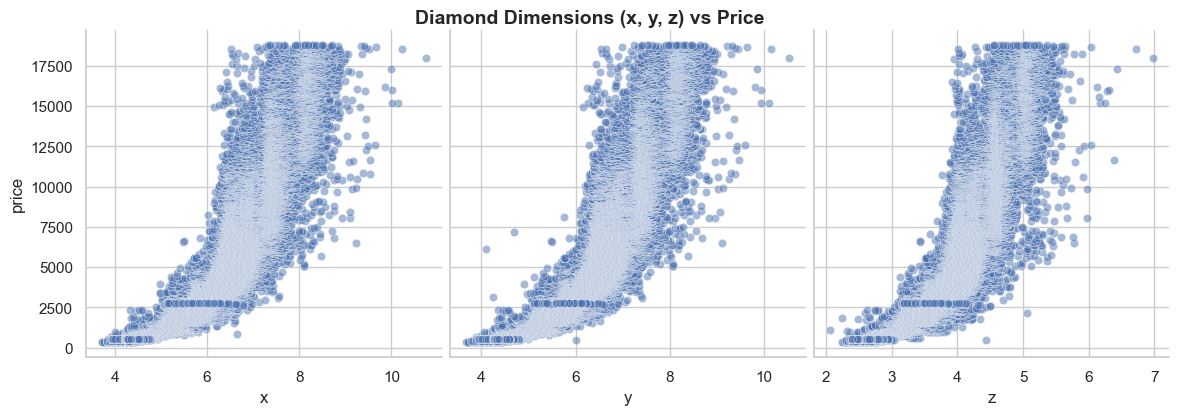

In [25]:
# Plot1: Create a scatter plot of carat vs price
sns.scatterplot(data=df, x="carat", y="price", alpha=0.5)

# Add title and labels
plt.title("Price by carat")
plt.xlabel("Carat")
plt.ylabel("Price")

# Show the plot
plt.show()

# Set Seaborn style
sns.set(style="whitegrid")

# Create a figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 2: Price by Cut
sns.boxplot(data=df, x="cut", y="price", palette="pastel", hue= "cut", legend = False, ax=axes[0])
axes[0].set_title("Price by Cut", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Cut Quality")
axes[0].set_ylabel("Price (USD)")

# Plot 3: Price by Color
sns.boxplot(data=df, x="color", y="price", palette="cool", hue= "color", legend = False, ax=axes[1])
axes[1].set_title("Price by Color", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Color Grade")
axes[1].set_ylabel("")

# Plot 4: Price by Clarity (with strip overlay for uniqueness)
sns.boxplot(data=df, x="clarity", y="price", palette="flare", hue= "clarity", legend = False, showfliers=False, ax=axes[2])
#sns.stripplot(data=df, x="clarity", y="price", color="black", alpha=0.3, jitter=0.2, ax=axes[2])
axes[2].set_title("Price by Clarity", fontsize=13, fontweight='bold')
axes[2].set_xlabel("Clarity Grade")
axes[2].set_ylabel("")

# Adjust layout for readability
plt.tight_layout()
plt.show()

# Plot 5: Diamond dimensions vs Price
sns.pairplot(df, x_vars=['x', 'y', 'z'], y_vars='price', height=4, aspect=1, kind='scatter', plot_kws={'alpha':0.5})
plt.suptitle("Diamond Dimensions (x, y, z) vs Price", y=1.02, fontsize=14, fontweight='bold')
plt.show()

### More visuals of value counts

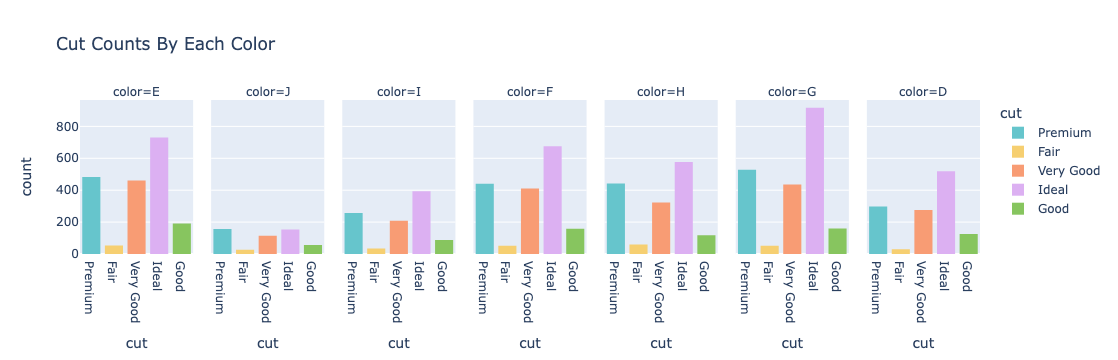

In [27]:
px.histogram(df.sample(n=10000, replace=False, random_state=123).sort_index(), x='cut', facet_col='color', color='cut', title='Cut Counts By Each Color', color_discrete_sequence=px.colors.qualitative.Pastel)

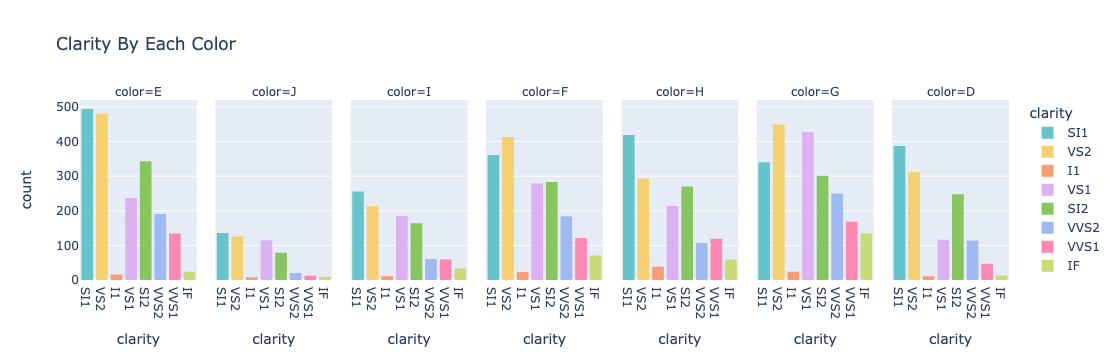

In [28]:
px.histogram(df.sample(n=10000, replace=False, random_state=123).sort_index(), x='clarity', facet_col='color', color='clarity', title='Clarity By Each Color', color_discrete_sequence=px.colors.qualitative.Pastel)

#### Visualizing the correlation of variables

               carat     depth     table     price         x         y  \
carat       1.000000  0.028718  0.181098  0.921546  0.977855  0.976940   
depth       0.028718  1.000000 -0.301988 -0.010766 -0.024679 -0.027810   
table       0.181098 -0.301988  1.000000  0.126425  0.195530  0.189325   
price       0.921546 -0.010766  0.126425  1.000000  0.887118  0.888708   
x           0.977855 -0.024679  0.195530  0.887118  1.000000  0.998654   
y           0.976940 -0.027810  0.189325  0.888708  0.998654  1.000000   
z           0.977069  0.097230  0.154900  0.882504  0.991666  0.991330   
is_outlier  0.265757 -0.014397  0.023555  0.356924  0.215334  0.216243   

                   z  is_outlier  
carat       0.977069    0.265757  
depth       0.097230   -0.014397  
table       0.154900    0.023555  
price       0.882504    0.356924  
x           0.991666    0.215334  
y           0.991330    0.216243  
z           1.000000    0.212344  
is_outlier  0.212344    1.000000  


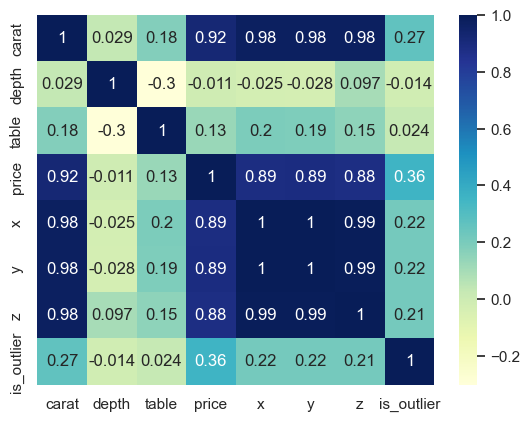

In [30]:
# Compute correlation matrix
co_mtx = df.corr(numeric_only=True)

# Print correlation matrix
print(co_mtx)

# Plot correlation heatmap
sns.heatmap(co_mtx, cmap="YlGnBu", annot=True)

# Display heatmap
plt.show()



# Data Modelling

In [32]:
#### Getting Categorical variables

d = (df.dtypes =="object")
object_cols = list(d[d].index)
print("Categorical variables:")
print(object_cols)

Categorical variables:
['cut', 'color', 'clarity']


#### Labelling data

In [34]:
label_data = df.copy()

# Apply label encoder to each column with categorical data
label_encoder = LabelEncoder()
for col in object_cols:
    label_data[col] = label_encoder.fit_transform(label_data[col])
label_data.head()

,carat,cut,color,clarity,depth,table,price,x,y,z,is_outlier
0,0.23,2,1,3,61.5,55.0,326,3.95,3.98,2.43,False
1,0.21,3,1,2,59.8,61.0,326,3.89,3.84,2.31,False
2,0.23,1,1,4,56.9,65.0,327,4.05,4.07,2.31,False
3,0.29,3,5,5,62.4,58.0,334,4.20,4.23,2.63,False
4,0.31,1,6,3,63.3,58.0,335,4.34,4.35,2.75,False


#### The XGB Regressor has the best scoring. Hence we will test this model on a test set, evaluating it with different parameters

In [36]:

#Feature Engineering
df = label_data.copy()
df['volume'] = df['x'] * df['y'] * df['z']
df['log_price'] = np.log1p(df['price'])

# Define features and target
X = df.drop(['price', 'log_price'], axis=1)
y = df['log_price']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=7)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ---- Define models ----
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=7),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=7),
    "XGBoost": XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=7, objective='reg:squarederror')
}

# Optional: Hyperparameter tuning for XGBoost
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

search = RandomizedSearchCV(models["XGBoost"], param_grid, n_iter=20, scoring='r2', cv=3, random_state=7, n_jobs=-1)
search.fit(X_train_scaled, y_train)
models["XGBoost"] = search.best_estimator_

# ---- Train, Predict, and Evaluate ----
results = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred_log = model.predict(X_test_scaled)
    y_pred = np.expm1(y_pred_log)  # Convert back from log
    y_test_actual = np.expm1(y_test)
    
    mse = mean_squared_error(y_test_actual, y_pred)
    mae = mean_absolute_error(y_test_actual, y_pred)
    r2 = r2_score(y_test_actual, y_pred)
    accuracy = np.mean(np.abs(y_pred - y_test_actual) / y_test_actual < 0.1) * 100  # within 10%
    
    results[name] = {
        "MSE": mse,
        "MAE": mae,
        "R2": r2,
        "Accuracy (10%)": accuracy
    }

# Display results
results_df = pd.DataFrame(results).T
print(results_df)

                            MSE         MAE        R2  Accuracy (10%)
Linear Regression  1.240667e+06  600.444873  0.920974       41.157652
Random Forest      2.614291e+05  259.082430  0.983348       80.209806
Gradient Boosting  2.611416e+05  274.906698  0.983366       74.592664
XGBoost            2.339016e+05  250.344012  0.985101       82.248345


#### The best model is XGBoost with an R2 value of 0.985 and accuracy of 82%

### Plotting Actual and Predicted Prices

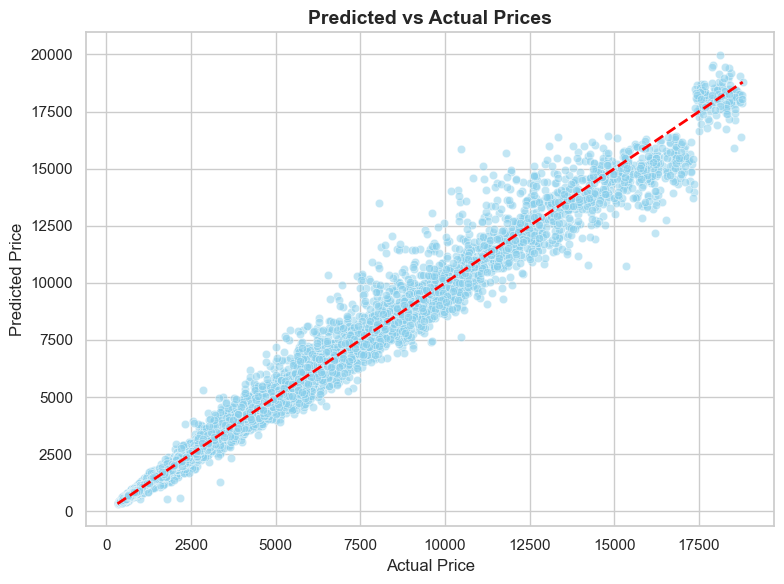

In [39]:
# Create a DataFrame for visualization
vis_df = pd.DataFrame({
    'Actual Price': y_test_actual,
    'Predicted Price': y_pred
})

plt.figure(figsize=(8, 6))
sns.scatterplot(x='Actual Price', y='Predicted Price', data=vis_df, alpha=0.5, color='skyblue')
plt.plot([y_test_actual.min(), y_test_actual.max()],
         [y_test_actual.min(), y_test_actual.max()],
         color='red', linewidth=2, linestyle='--')  # reference line for perfect prediction
plt.title('Predicted vs Actual Prices', fontsize=14, fontweight='bold')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.tight_layout()
plt.show()